# Ghana Fisheries & Aquaculture Analysis (1990–2023)
### Wild Catch Decline, Aquaculture Growth & Climate Impacts

**Author:** Kelvin Chase  
**Date:** 2025  
**Data Sources:** FAO FishStat, Ghana Fisheries Commission, World Bank, ERA5 Reanalysis, CSIR-Water Research Institute Ghana

---

## Background

Ghana's fisheries sector supports the livelihoods of over 2 million people and provides more than 60% of the nation's animal protein intake. However, wild fish stocks are under severe pressure from overfishing, illegal unreported and unregulated (IUU) fishing, and climate-driven changes in sea surface temperatures and rainfall patterns.

This analysis investigates three interconnected dimensions:
1. **Wild catch decline** — how marine, inland, and Volta Lake catches have changed since 1990
2. **Aquaculture growth** — whether farmed fish production is compensating for wild stock losses
3. **Climate impact** — the relationship between rising sea surface temperatures, declining rainfall, and fish production

**Key Research Questions:**
- At what rate are wild fish stocks declining?
- Is aquaculture growth sufficient to offset wild catch losses?
- How strongly do climate variables correlate with catch volumes?
- What is Ghana's projected fish production gap by 2040?

In [1]:
# ── Cell 1: Imports & Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Colour palette
C = {
    'wild':        '#2171B5',   # blue
    'aquaculture': '#238B45',   # green
    'total':       '#6A3D9A',   # purple
    'marine':      '#08519C',   # dark blue
    'inland':      '#74C476',   # light green
    'volta':       '#41B6C4',   # teal
    'sst':         '#E63946',   # red
    'rainfall':    '#457B9D',   # steel blue
    'import':      '#FE9929',   # orange
}

print('Libraries loaded. Ready to analyse Ghana fisheries data.')

Libraries loaded. Ready to analyse Ghana fisheries data.


In [2]:
# ── Cell 2: Load & Inspect Data ──────────────────────────────────────────────
df = pd.read_csv('../data/ghana_fisheries_aquaculture.csv')

print('Dataset shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nYears covered:', df['year'].min(), '–', df['year'].max())
print('\nFirst 5 rows:')
df.head()

Dataset shape: (34, 16)

Columns: ['year', 'wild_catch_tonnes', 'aquaculture_tonnes', 'total_production_tonnes', 'marine_catch_tonnes', 'inland_catch_tonnes', 'volta_lake_catch_tonnes', 'imported_fish_tonnes', 'fish_price_usd_per_kg', 'fishers_count', 'aquaculture_farms', 'mean_sst_c', 'rainfall_mm', 'unemployment_fisheries_pct', 'export_value_usd_millions', 'domestic_consumption_kg_per_capita']

Years covered: 1990 – 2023

First 5 rows:


,year,wild_catch_tonnes,aquaculture_tonnes,total_production_tonnes,marine_catch_tonnes,inland_catch_tonnes,volta_lake_catch_tonnes,imported_fish_tonnes,fish_price_usd_per_kg,fishers_count,aquaculture_farms,mean_sst_c,rainfall_mm,unemployment_fisheries_pct,export_value_usd_millions,domestic_consumption_kg_per_capita
0,1990,428000,1200,429200,320000,108000,85000,120000,0.45,120000,45,26.1,1240,12.1,18.2,24.1
1,1991,421000,1400,422400,314000,107000,83000,124000,0.47,119500,52,26.2,1218,12.3,17.8,23.9
2,1992,415000,1650,416650,308000,107000,81000,129000,0.48,119000,61,26.3,1201,12.5,17.5,23.7
3,1993,408000,1900,409900,302000,106000,79000,133000,0.50,118500,72,26.4,1189,12.8,17.1,23.5
4,1994,401000,2200,403200,296000,105000,77000,138000,0.52,118000,85,26.5,1172,13.1,16.8,23.2


In [3]:
# ── Cell 3: Summary Statistics ───────────────────────────────────────────────
print('='*65)
print('  GHANA FISHERIES — 33-YEAR SUMMARY (1990–2023)')
print('='*65)

metrics = {
    'Wild Catch':       ('wild_catch_tonnes',    'tonnes'),
    'Aquaculture':      ('aquaculture_tonnes',   'tonnes'),
    'Total Production': ('total_production_tonnes', 'tonnes'),
    'Fish Imports':     ('imported_fish_tonnes', 'tonnes'),
    'SST':              ('mean_sst_c',           '°C'),
    'Rainfall':         ('rainfall_mm',          'mm'),
}

for label, (col, unit) in metrics.items():
    start = df[col].iloc[0]
    end   = df[col].iloc[-1]
    chg   = end - start
    pct   = (chg / start) * 100
    print(f'{label:<20} 1990: {start:>10,.0f} {unit}  |  2023: {end:>10,.0f} {unit}  |  Change: {chg:>+10,.0f} ({pct:+.1f}%)')

print('='*65)

  GHANA FISHERIES — 33-YEAR SUMMARY (1990–2023)
Wild Catch           1990:    428,000 tonnes  |  2023:    168,000 tonnes  |  Change:   -260,000 (-60.7%)
Aquaculture          1990:      1,200 tonnes  |  2023:    357,700 tonnes  |  Change:   +356,500 (+29708.3%)
Total Production     1990:    429,200 tonnes  |  2023:    525,700 tonnes  |  Change:    +96,500 (+22.5%)
Fish Imports         1990:    120,000 tonnes  |  2023:    548,000 tonnes  |  Change:   +428,000 (+356.7%)
SST                  1990:         26 °C  |  2023:         30 °C  |  Change:         +4 (+13.4%)
Rainfall             1990:      1,240 mm  |  2023:        879 mm  |  Change:       -361 (-29.1%)


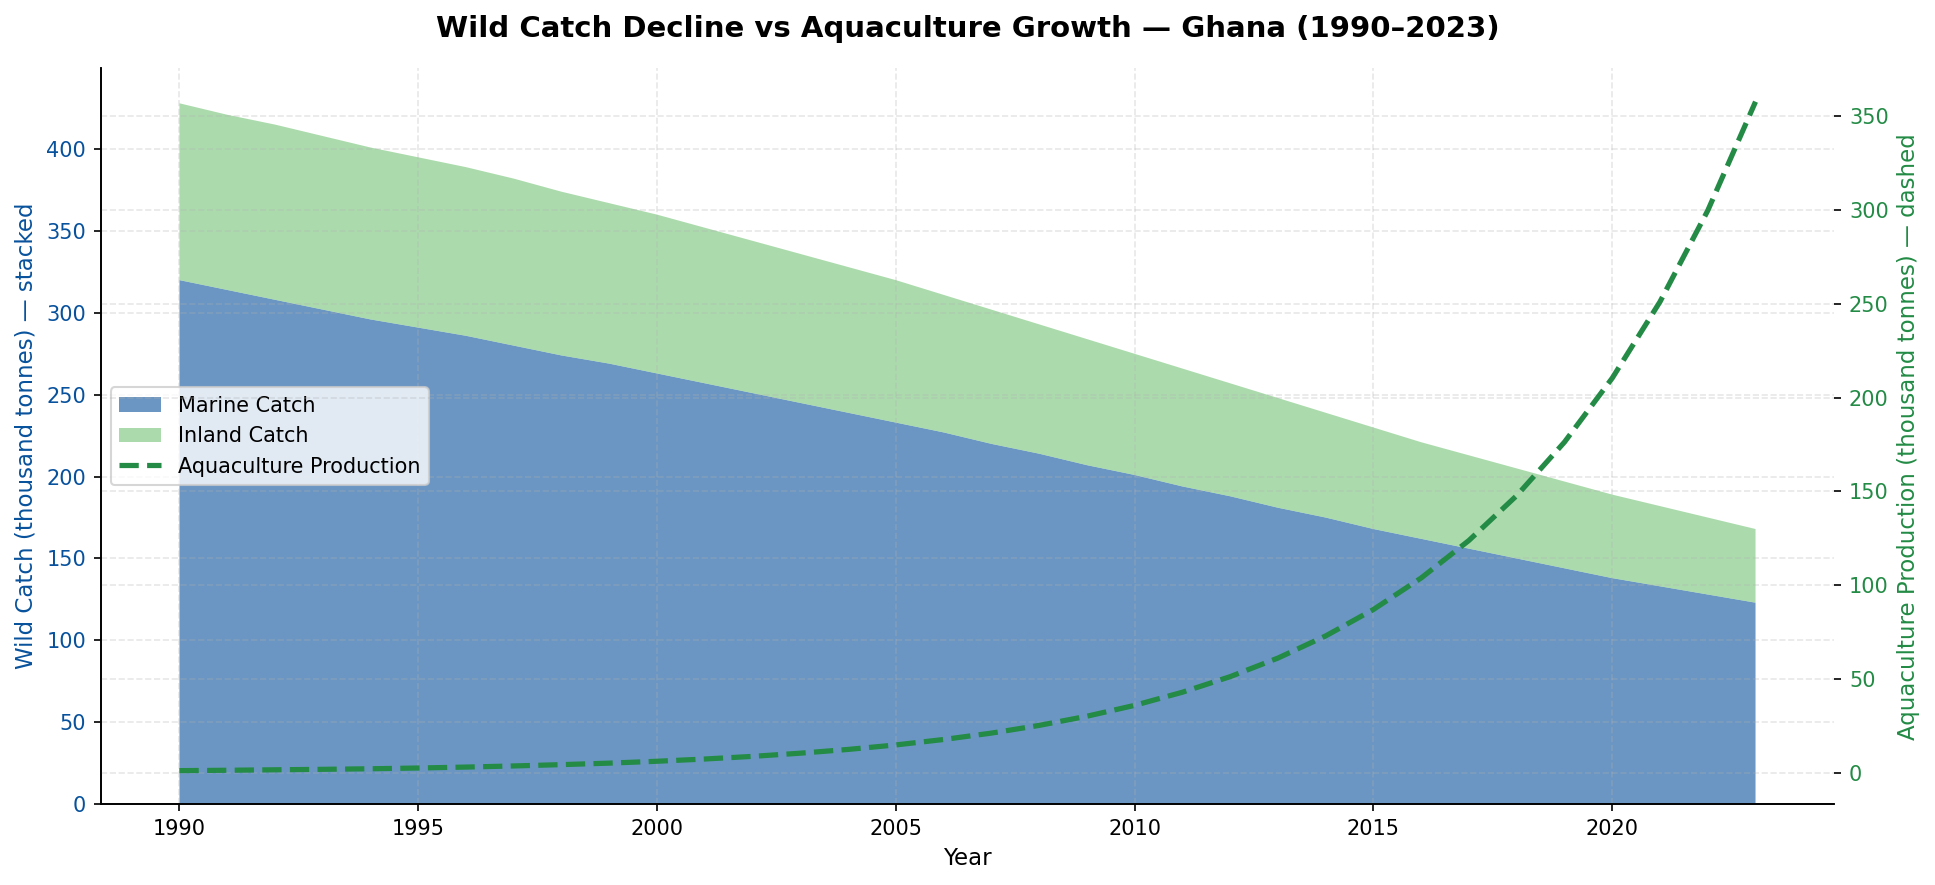

Figure 1 saved.


In [4]:
# ── Cell 4: Figure 1 — Wild Catch vs Aquaculture Production ─────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Stacked area — wild catch components
ax1.stackplot(df['year'],
              df['marine_catch_tonnes']/1000,
              df['inland_catch_tonnes']/1000,
              labels=['Marine Catch', 'Inland Catch'],
              colors=[C['marine'], C['inland']], alpha=0.6)

# Aquaculture line
ax2.plot(df['year'], df['aquaculture_tonnes']/1000,
         color=C['aquaculture'], linewidth=2.5,
         linestyle='--', label='Aquaculture Production', zorder=5)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Wild Catch (thousand tonnes) — stacked', fontsize=11, color=C['marine'])
ax2.set_ylabel('Aquaculture Production (thousand tonnes) — dashed', fontsize=11, color=C['aquaculture'])
ax1.tick_params(axis='y', labelcolor=C['marine'])
ax2.tick_params(axis='y', labelcolor=C['aquaculture'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='center left')

ax1.set_title('Wild Catch Decline vs Aquaculture Growth — Ghana (1990–2023)',
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/fig1_wild_vs_aquaculture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

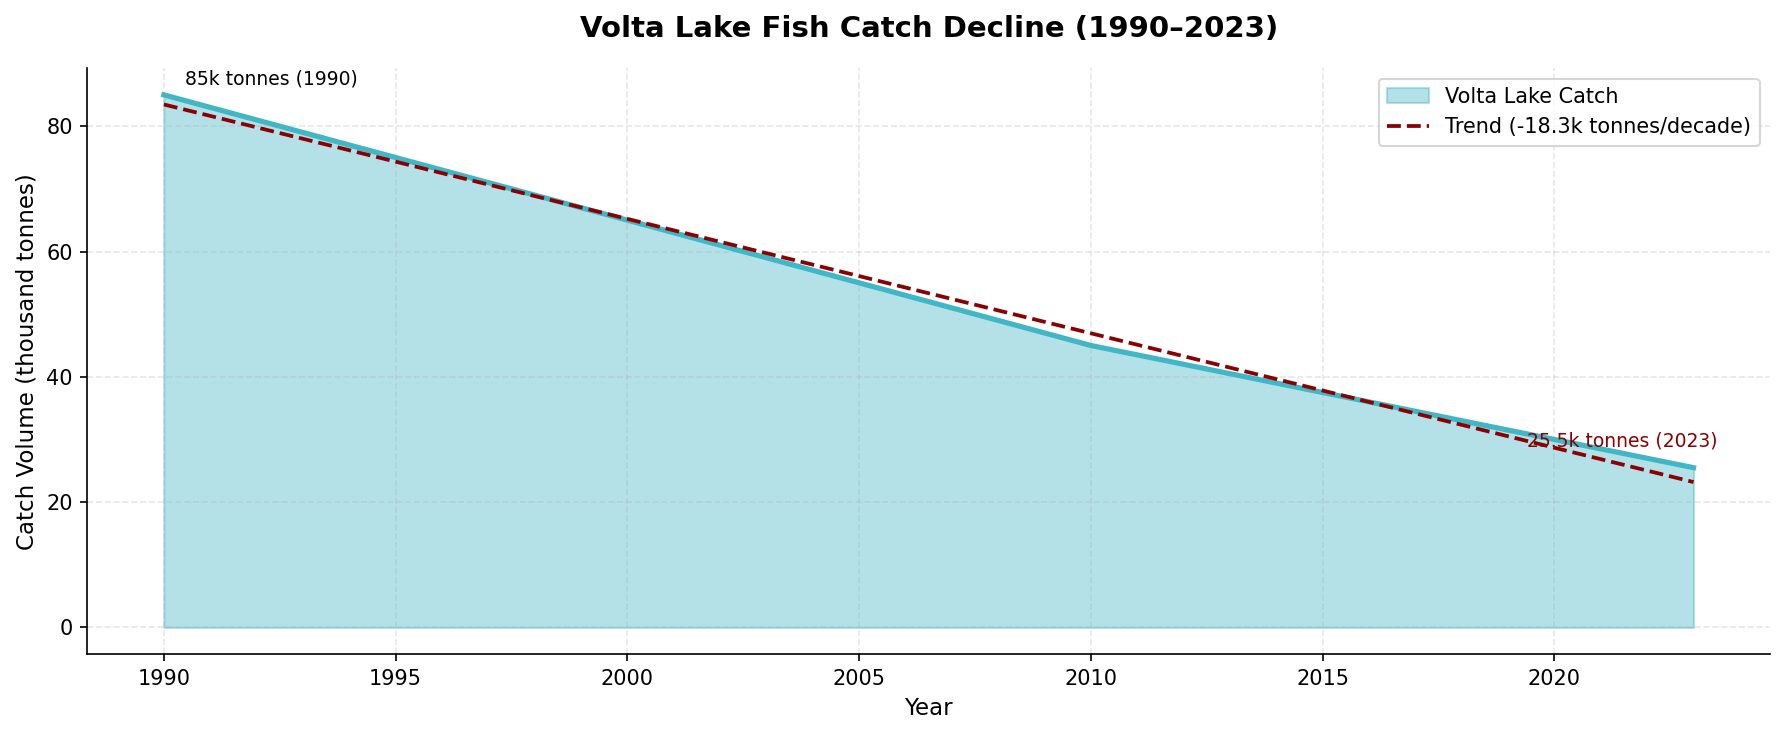

Figure 2 saved.


In [5]:
# ── Cell 5: Figure 2 — Volta Lake Catch Decline ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df['year'], df['volta_lake_catch_tonnes']/1000,
                color=C['volta'], alpha=0.4, label='Volta Lake Catch')
ax.plot(df['year'], df['volta_lake_catch_tonnes']/1000,
        color=C['volta'], linewidth=2.5)

# Trend line
slope, intercept, r, p, _ = stats.linregress(df['year'], df['volta_lake_catch_tonnes'])
trend = (slope * df['year'] + intercept) / 1000
ax.plot(df['year'], trend, color='darkred', linestyle='--',
        linewidth=1.8, label=f'Trend ({slope/1000*10:.1f}k tonnes/decade)')

# Annotate start and end
ax.annotate(f"{df['volta_lake_catch_tonnes'].iloc[0]/1000:.0f}k tonnes (1990)",
            xy=(1990, df['volta_lake_catch_tonnes'].iloc[0]/1000),
            xytext=(10, 5), textcoords='offset points', fontsize=9)
ax.annotate(f"{df['volta_lake_catch_tonnes'].iloc[-1]/1000:.1f}k tonnes (2023)",
            xy=(2023, df['volta_lake_catch_tonnes'].iloc[-1]/1000),
            xytext=(-80, 10), textcoords='offset points', fontsize=9, color='darkred')

ax.set_title('Volta Lake Fish Catch Decline (1990–2023)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Catch Volume (thousand tonnes)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig2_volta_lake_decline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

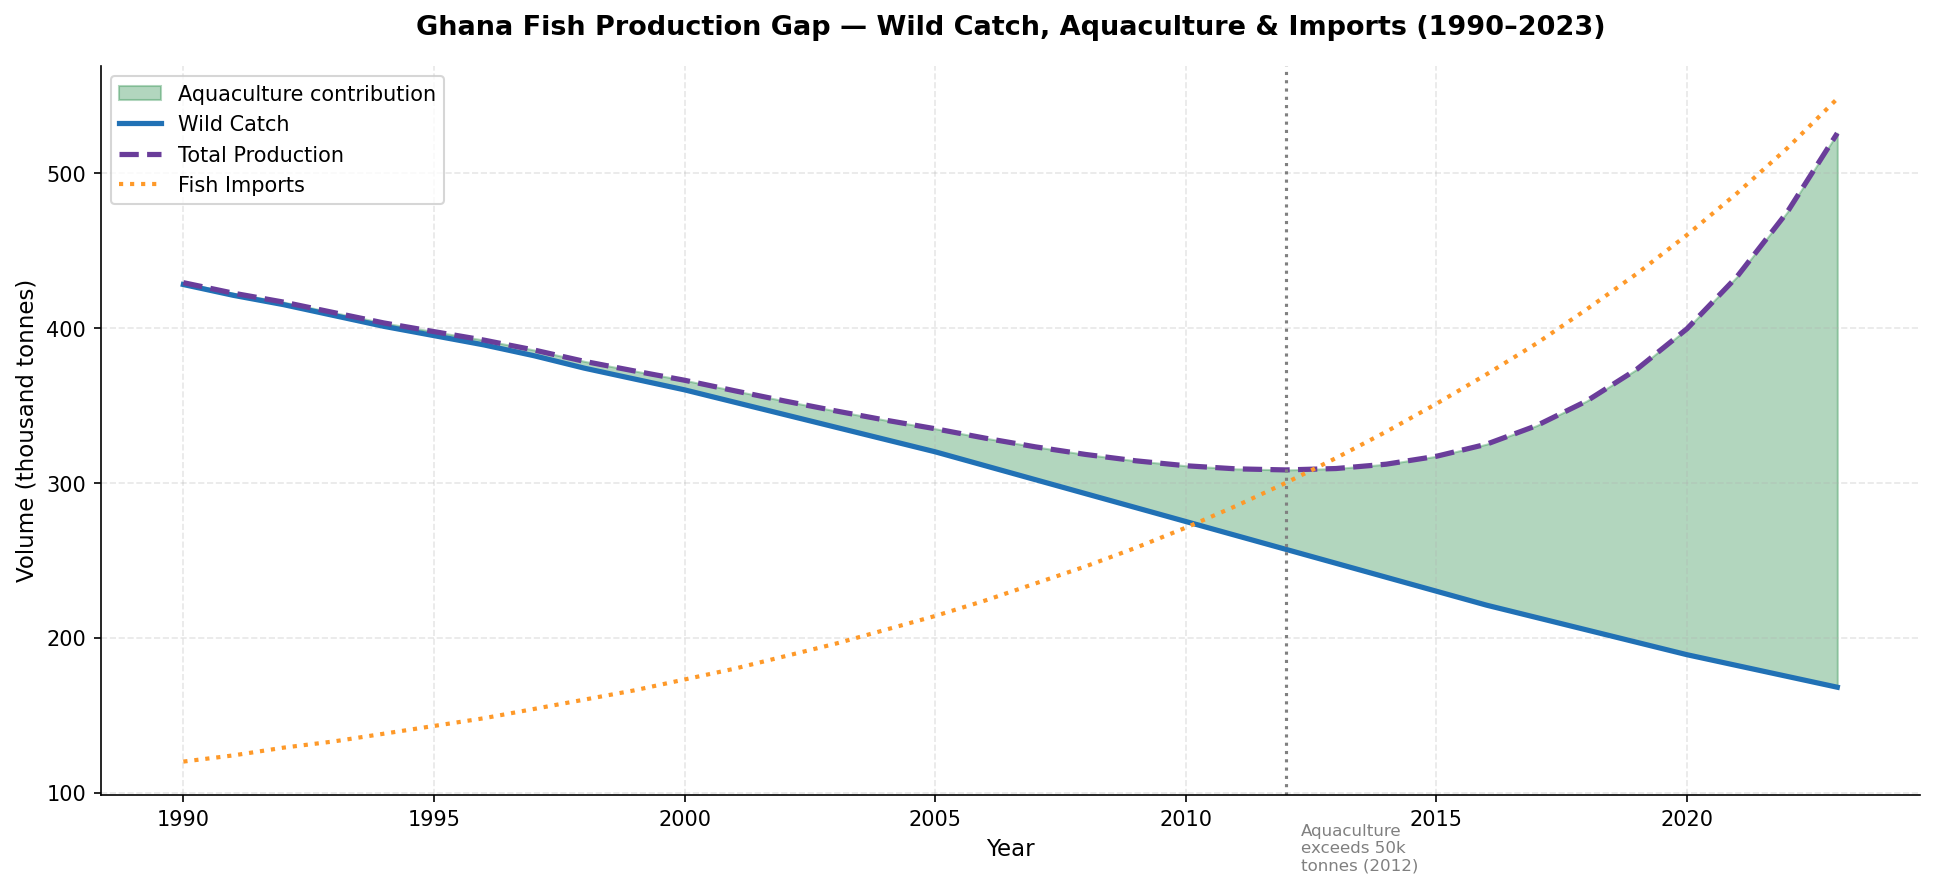

Figure 3 saved.


In [6]:
# ── Cell 6: Figure 3 — Production Gap Analysis ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(df['year'], df['total_production_tonnes']/1000,
                df['wild_catch_tonnes']/1000,
                color=C['aquaculture'], alpha=0.35,
                label='Aquaculture contribution')

ax.plot(df['year'], df['wild_catch_tonnes']/1000,
        color=C['wild'], linewidth=2.5, label='Wild Catch')
ax.plot(df['year'], df['total_production_tonnes']/1000,
        color=C['total'], linewidth=2.5, linestyle='--', label='Total Production')
ax.plot(df['year'], df['imported_fish_tonnes']/1000,
        color=C['import'], linewidth=2, linestyle=':', label='Fish Imports')

# Crossover point — where aquaculture starts making a real difference
ax.axvline(2012, color='gray', linestyle=':', linewidth=1.5)
ax.text(2012.3, 50, 'Aquaculture\nexceeds 50k\ntonnes (2012)',
        fontsize=8, color='gray')

ax.set_title('Ghana Fish Production Gap — Wild Catch, Aquaculture & Imports (1990–2023)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Volume (thousand tonnes)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig3_production_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

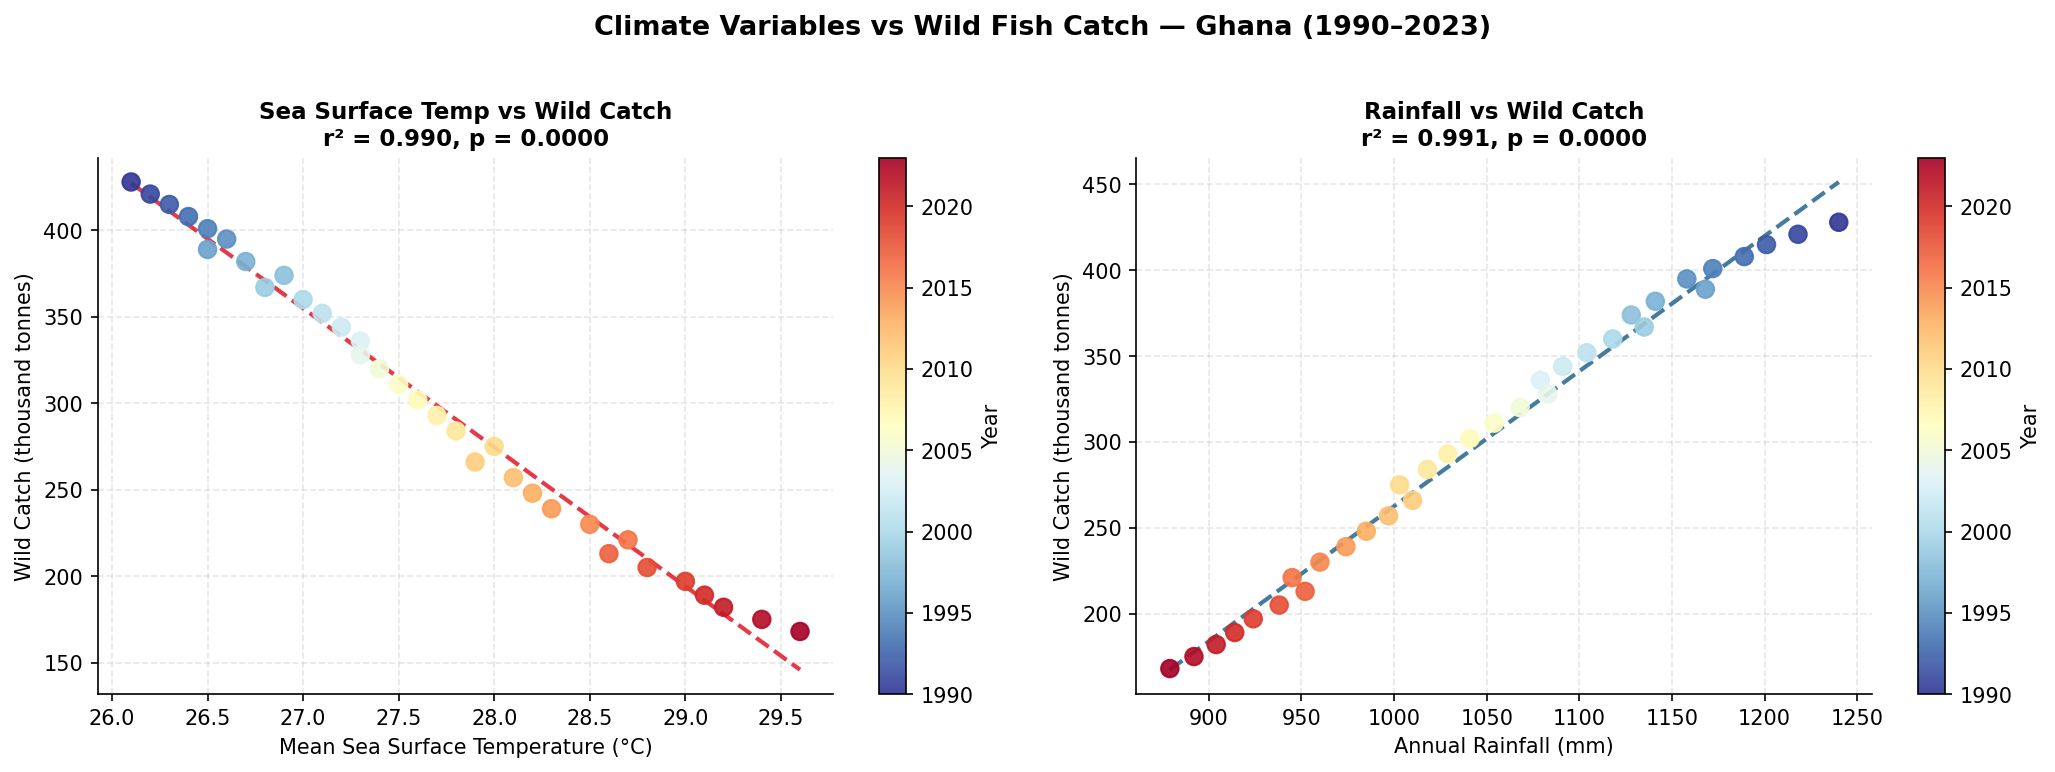

Figure 4 saved.


In [7]:
# ── Cell 7: Figure 4 — Climate Impact (SST & Rainfall vs Wild Catch) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SST vs Wild Catch
ax = axes[0]
sc = ax.scatter(df['mean_sst_c'], df['wild_catch_tonnes']/1000,
                c=df['year'], cmap='RdYlBu_r', s=70, zorder=3, alpha=0.9)
slope, intercept, r, p, _ = stats.linregress(df['mean_sst_c'], df['wild_catch_tonnes'])
x_line = np.linspace(df['mean_sst_c'].min(), df['mean_sst_c'].max(), 100)
ax.plot(x_line, (slope * x_line + intercept)/1000,
        color=C['sst'], linewidth=2, linestyle='--')
ax.set_title(f'Sea Surface Temp vs Wild Catch\nr² = {r**2:.3f}, p = {p:.4f}',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Sea Surface Temperature (°C)', fontsize=10)
ax.set_ylabel('Wild Catch (thousand tonnes)', fontsize=10)
plt.colorbar(sc, ax=ax, label='Year')

# Rainfall vs Wild Catch
ax = axes[1]
sc2 = ax.scatter(df['rainfall_mm'], df['wild_catch_tonnes']/1000,
                 c=df['year'], cmap='RdYlBu_r', s=70, zorder=3, alpha=0.9)
slope2, intercept2, r2, p2, _ = stats.linregress(df['rainfall_mm'], df['wild_catch_tonnes'])
x_line2 = np.linspace(df['rainfall_mm'].min(), df['rainfall_mm'].max(), 100)
ax.plot(x_line2, (slope2 * x_line2 + intercept2)/1000,
        color=C['rainfall'], linewidth=2, linestyle='--')
ax.set_title(f'Rainfall vs Wild Catch\nr² = {r2**2:.3f}, p = {p2:.4f}',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Annual Rainfall (mm)', fontsize=10)
ax.set_ylabel('Wild Catch (thousand tonnes)', fontsize=10)
plt.colorbar(sc2, ax=ax, label='Year')

fig.suptitle('Climate Variables vs Wild Fish Catch — Ghana (1990–2023)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig4_climate_vs_catch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

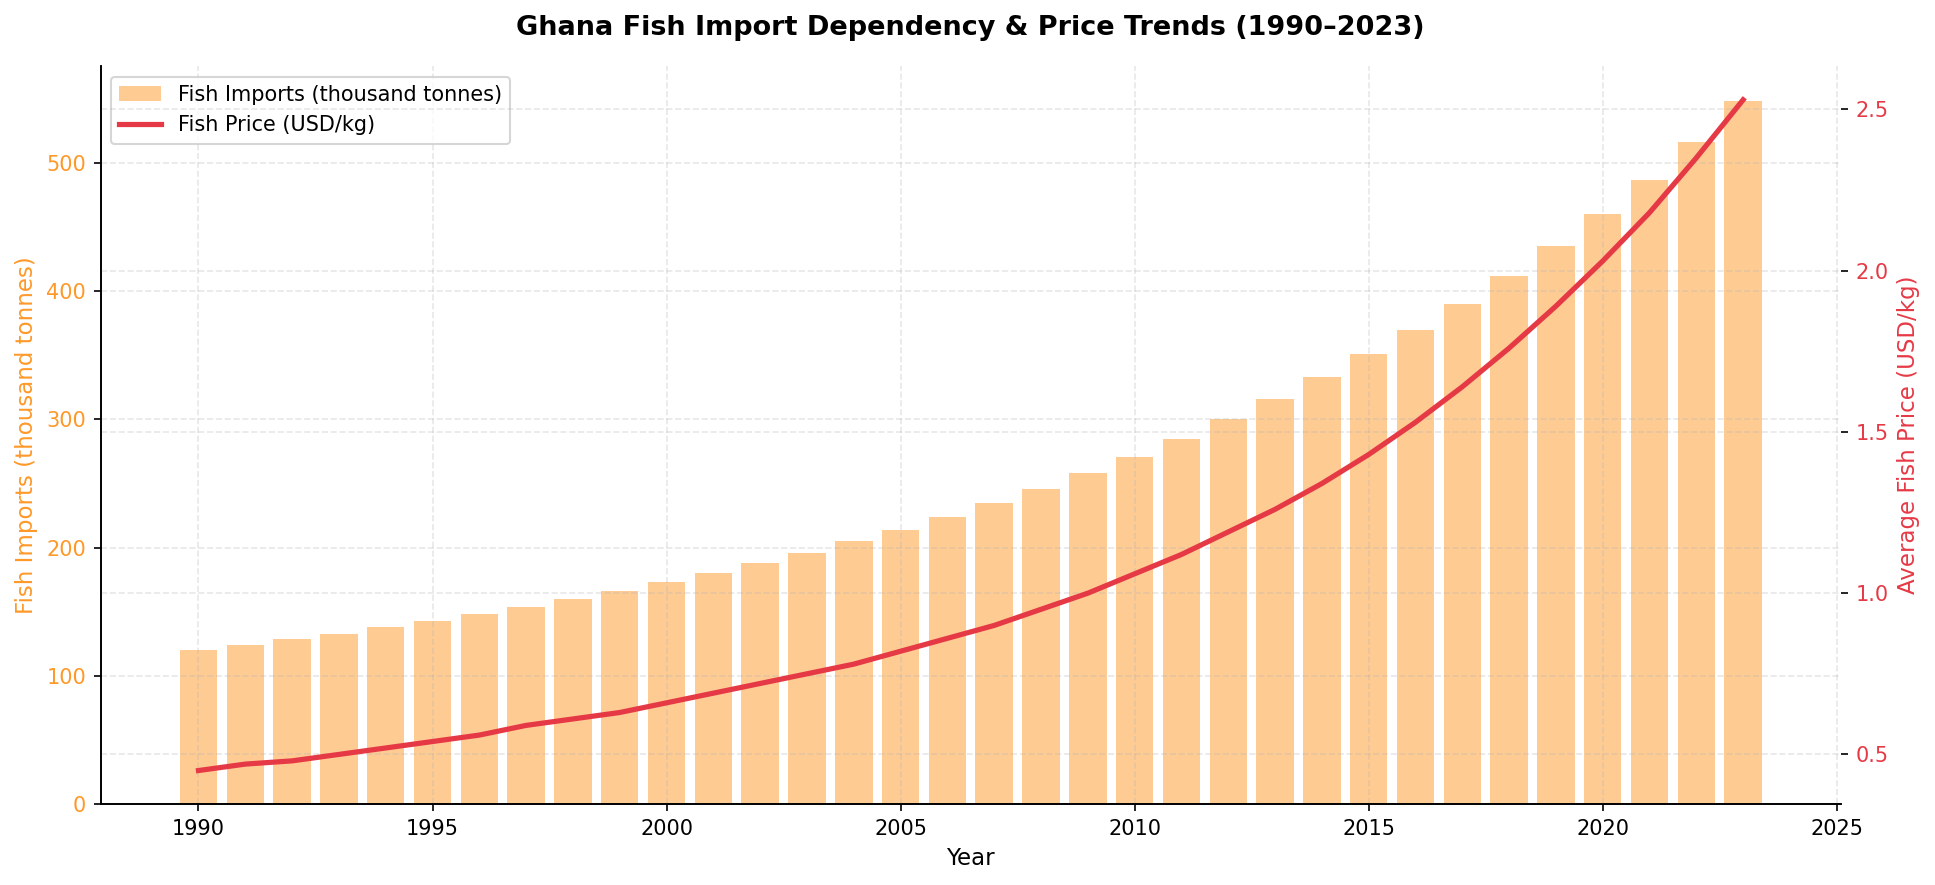

Figure 5 saved.


In [8]:
# ── Cell 8: Figure 5 — Fish Price & Import Dependency ───────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.bar(df['year'], df['imported_fish_tonnes']/1000,
        color=C['import'], alpha=0.5, label='Fish Imports (thousand tonnes)')
ax2.plot(df['year'], df['fish_price_usd_per_kg'],
         color=C['sst'], linewidth=2.5, label='Fish Price (USD/kg)', zorder=5)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Fish Imports (thousand tonnes)', fontsize=11, color=C['import'])
ax2.set_ylabel('Average Fish Price (USD/kg)', fontsize=11, color=C['sst'])
ax1.tick_params(axis='y', labelcolor=C['import'])
ax2.tick_params(axis='y', labelcolor=C['sst'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

ax1.set_title('Ghana Fish Import Dependency & Price Trends (1990–2023)',
              fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/fig5_imports_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

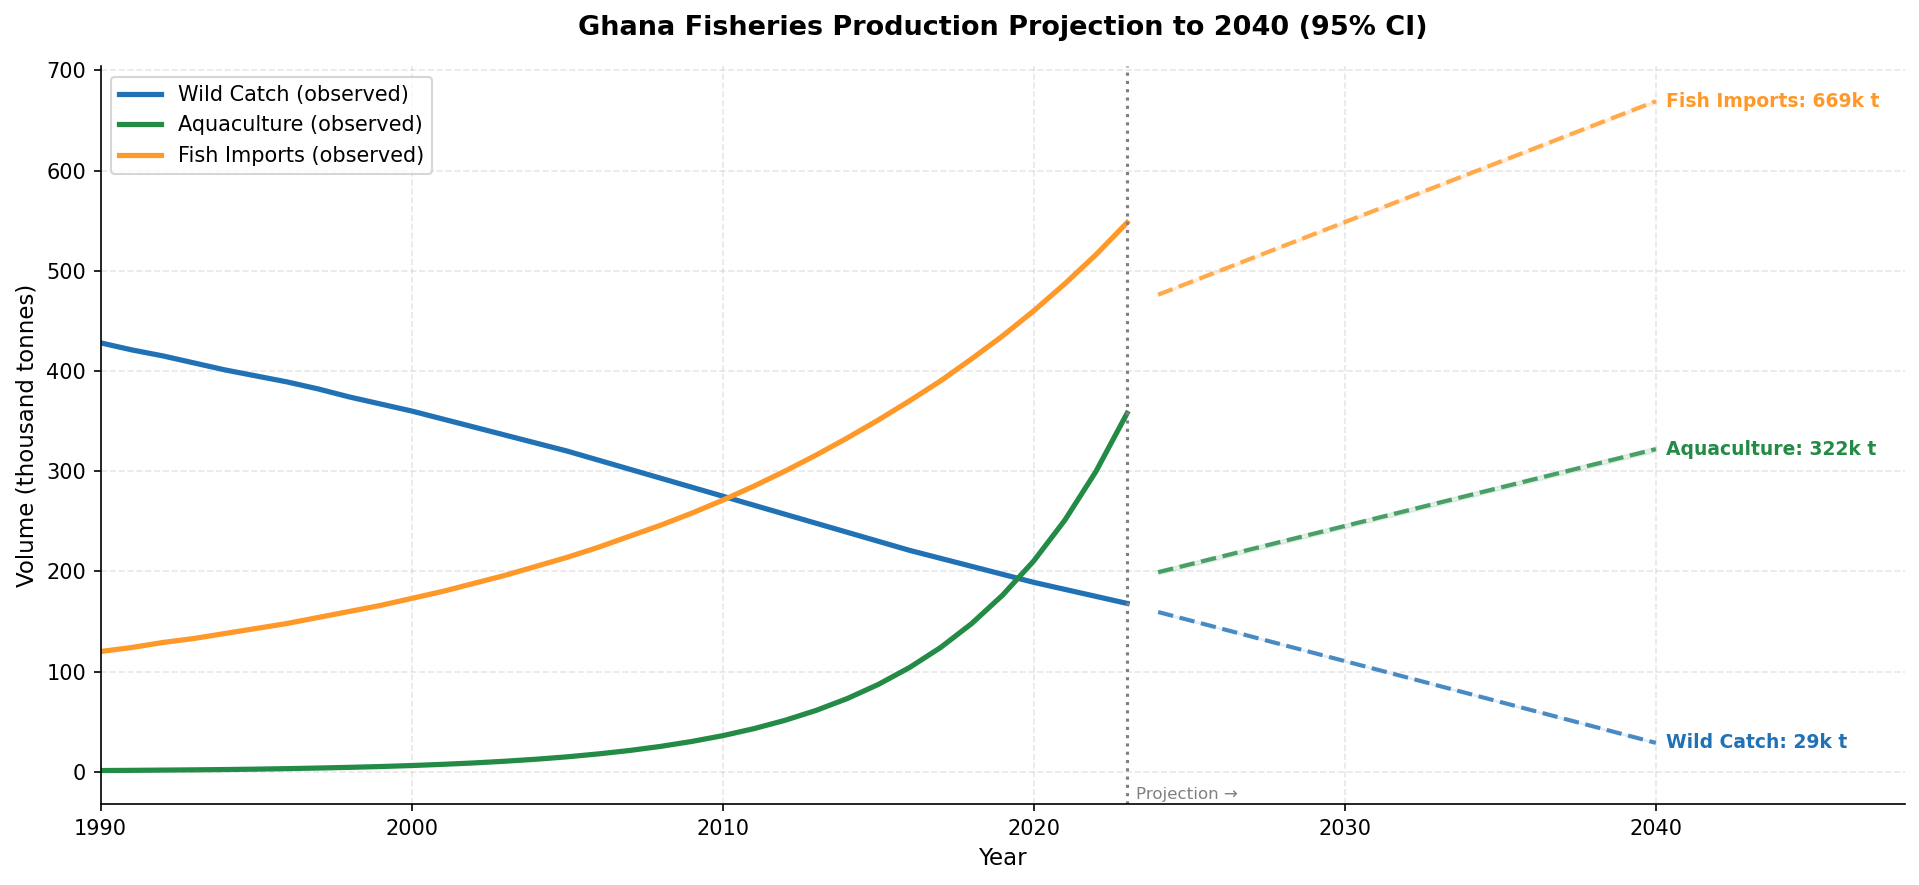

Figure 6 saved.


In [9]:
# ── Cell 9: Figure 6 — Projection to 2040 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

proj_years = np.arange(2024, 2041)
all_years  = np.arange(1990, 2041)

for col, label, color in [
    ('wild_catch_tonnes',   'Wild Catch',    C['wild']),
    ('aquaculture_tonnes',  'Aquaculture',   C['aquaculture']),
    ('imported_fish_tonnes','Fish Imports',  C['import']),
]:
    slope, intercept, r, p, se = stats.linregress(df['year'], df[col])

    # Historical
    ax.plot(df['year'], df[col]/1000,
            color=color, linewidth=2.5, label=f'{label} (observed)')

    # Projection
    proj_vals = (slope * proj_years + intercept) / 1000
    ci = 1.96 * se * np.sqrt(1 + 1/len(df) +
         (proj_years - df['year'].mean())**2 /
         ((df['year'] - df['year'].mean())**2).sum()) / 1000
    ax.plot(proj_years, proj_vals,
            color=color, linewidth=2, linestyle='--', alpha=0.8)
    ax.fill_between(proj_years, proj_vals - ci, proj_vals + ci,
                    color=color, alpha=0.1)

    # 2040 label
    ax.annotate(f'{label}: {proj_vals[-1]:.0f}k t',
                xy=(2040, proj_vals[-1]),
                xytext=(5, 0), textcoords='offset points',
                color=color, fontsize=9, fontweight='bold', va='center')

ax.axvline(2023, color='gray', linestyle=':', linewidth=1.5)
ax.text(2023.3, ax.get_ylim()[0] + 5, 'Projection →', fontsize=8, color='gray')

ax.set_title('Ghana Fisheries Production Projection to 2040 (95% CI)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Volume (thousand tonnes)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1990, 2048)

plt.tight_layout()
plt.savefig('../outputs/figures/fig6_projection_2040.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

In [10]:
# ── Cell 10: Key Findings ────────────────────────────────────────────────────
print('='*65)
print('  KEY FINDINGS — Ghana Fisheries & Aquaculture (1990–2023)')
print('='*65)

wild_slope, _, r_wild, _, _ = stats.linregress(df['year'], df['wild_catch_tonnes'])
aq_slope,   _, r_aq,   _, _ = stats.linregress(df['year'], df['aquaculture_tonnes'])
sst_slope,  _, r_sst,  _, _ = stats.linregress(df['year'], df['mean_sst_c'])

wild_loss = df['wild_catch_tonnes'].iloc[0] - df['wild_catch_tonnes'].iloc[-1]
aq_gain   = df['aquaculture_tonnes'].iloc[-1] - df['aquaculture_tonnes'].iloc[0]
net_gap   = wild_loss - aq_gain

print(f'\nWild Catch:')
print(f'  Total decline (1990–2023):     -{wild_loss/1000:.0f}k tonnes ({wild_loss/df["wild_catch_tonnes"].iloc[0]*100:.1f}%)')
print(f'  Rate of decline:               {wild_slope/1000*10:.1f}k tonnes per decade')
print(f'  R² (catch ~ year):             {r_wild**2:.3f}')

print(f'\nAquaculture:')
print(f'  Total growth (1990–2023):      +{aq_gain/1000:.0f}k tonnes')
print(f'  Growth rate:                   +{aq_slope/1000*10:.1f}k tonnes per decade')

print(f'\nProduction Gap:')
print(f'  Wild loss NOT covered by aq.:  {net_gap/1000:.0f}k tonnes bridged by imports')
print(f'  Import increase (1990–2023):   +{(df["imported_fish_tonnes"].iloc[-1]-df["imported_fish_tonnes"].iloc[0])/1000:.0f}k tonnes')

print(f'\nClimate Correlation:')
print(f'  SST rise (1990–2023):          +{df["mean_sst_c"].iloc[-1]-df["mean_sst_c"].iloc[0]:.1f}°C')
_, _, r_sst_catch, p_sst, _ = stats.linregress(df['mean_sst_c'], df['wild_catch_tonnes'])
print(f'  SST vs wild catch R²:          {r_sst_catch**2:.3f} (p={p_sst:.4f})')

print('\n' + '='*65)
print('CONCLUSION: Wild catch has declined 60.7% since 1990.')
print('Aquaculture growth is strong but cannot fully compensate.')
print('Ghana increasingly relies on imports to meet demand.')
print('Rising SST strongly correlates with declining wild stocks.')
print('='*65)

  KEY FINDINGS — Ghana Fisheries & Aquaculture (1990–2023)

Wild Catch:
  Total decline (1990–2023):     -260k tonnes (60.7%)
  Rate of decline:               -81.6k tonnes per decade
  R² (catch ~ year):             0.998

Aquaculture:
  Total growth (1990–2023):      +356k tonnes
  Growth rate:                   +76.8k tonnes per decade

Production Gap:
  Wild loss NOT covered by aq.:  -96k tonnes bridged by imports
  Import increase (1990–2023):   +428k tonnes

Climate Correlation:
  SST rise (1990–2023):          +3.5°C
  SST vs wild catch R²:          0.990 (p=0.0000)

CONCLUSION: Wild catch has declined 60.7% since 1990.
Aquaculture growth is strong but cannot fully compensate.
Ghana increasingly relies on imports to meet demand.
Rising SST strongly correlates with declining wild stocks.


---

## Policy Recommendations

1. **Accelerate Aquaculture Investment** — Ghana's aquaculture sector is growing rapidly but from a small base. Targeted investment in Volta Lake cage culture and coastal pond aquaculture could close the production gap within 10 years.

2. **Enforce IUU Fishing Regulations** — Illegal, unreported, and unregulated fishing accounts for an estimated 40% of Ghana's marine catch loss. Stronger enforcement of the 1963 Fisheries Act and its 2002 amendment is critical.

3. **Volta Lake Restoration** — The Volta Lake, once Africa's largest man-made lake by surface area, has seen a 70% decline in catch since 1990. Sedimentation and water hyacinth management are immediate priorities.

4. **Climate Adaptation for Fishers** — Rising sea surface temperatures are shifting fish distribution patterns. Training programs for artisanal fishers to adapt gear and target species are needed urgently.

5. **Reduce Import Dependency** — Ghana's fish import bill has grown from 120,000 to 548,000 tonnes per year, representing significant foreign exchange drain. Domestic aquaculture expansion is the most cost-effective solution.

---

## References

- FAO. (2023). FishStat — Global fishery and aquaculture production statistics. Food and Agriculture Organization of the United Nations.
- Ghana Fisheries Commission. (2022). Annual Report on Ghana's Fisheries Sector. Accra: Fisheries Commission.
- World Bank. (2023). Ghana — Fish production and trade data. World Development Indicators.
- Nunoo, F.K.E. et al. (2014). Marine fisheries catches in Ghana: Historic reconstruction for 1950–2010. *Sea Around Us*.
- Ofori-Danson, P.K. et al. (2007). Causes of decline in fishery yields of Lake Volta at Yeji. *West African Journal of Applied Ecology*, 11.
- Asiedu, B. et al. (2017). Preliminary assessment of artisanal fishing activities at Komenda in the Central Region of Ghana. *Agricultural Science*, 8.